In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data_dir = Path('log/logs_final/logs_icc/')

In [3]:
full_scales = pd.read_csv(data_dir / 'result_ICC_origscales_forplot_mostcombined_indecivinessenriched.csv')
cores = pd.read_csv(data_dir / 'result_ICC_invariantonly_combined.csv')

In [4]:
full_scales

,Measure,Type,ICC,F,df1,df2,pval,CI95,lci,uci
0,hitop_sum,"ICC(A,1)",0.9310,28.0037,652,652,0.0,[0.92 0.94],0.92,0.94
1,baars_sum,"ICC(A,1)",0.9002,19.0484,652,652,0.0,[0.88 0.91],0.88,0.91
2,phq_sum,"ICC(A,1)",0.9068,20.4662,652,652,0.0,[0.89 0.92],0.89,0.92
3,gad_sum,"ICC(A,1)",0.8733,14.7622,652,652,0.0,[0.85 0.89],0.85,0.89
4,baars_inattention_sum,"ICC(A,1)",0.8836,16.1565,652,652,0.0,[0.87 0.9 ],0.87,0.90
5,baars_hyperactivity_sum,"ICC(A,1)",0.8043,9.2722,652,652,0.0,[0.78 0.83],0.78,0.83
6,baars_impulsivity_sum,"ICC(A,1)",0.8285,10.6452,652,652,0.0,[0.8 0.85],0.80,0.85
7,baars_sct_sum,"ICC(A,1)",0.8799,15.6284,652,652,0.0,[0.86 0.9 ],0.86,0.90
8,hitop_anhedonic_depression,"ICC(A,1)",0.9041,19.9053,652,652,0.0,[0.89 0.92],0.89,0.92
9,hitop_anxious_worry,"ICC(A,1)",0.8981,18.6324,652,652,0.0,[0.88 0.91],0.88,0.91


In [5]:
cores

,Measure,Type,ICC,F,df1,df2,pval,CI95,lci,uci
0,hitop_anhedonic_depression_invcore,"ICC(A,1)",0.8845,16.3476,652,652,0.0,[0.87 0.9 ],0.87,0.90
1,hitop_anxious_worry_invcore,"ICC(A,1)",0.8774,15.3212,652,652,0.0,[0.86 0.89],0.86,0.89
2,hitop_appetite_gain_invcore,"ICC(A,1)",0.8217,10.2220,652,652,0.0,[0.8 0.85],0.80,0.85
3,hitop_separation_insecurity_invcore,"ICC(A,1)",0.8644,13.8001,652,652,0.0,[0.84 0.88],0.84,0.88
4,hitop_situational_phobia_invcore,"ICC(A,1)",0.7835,8.2269,652,652,0.0,[0.75 0.81],0.75,0.81
5,hitop_social_anxiety_invcore,"ICC(A,1)",0.8742,14.8754,652,652,0.0,[0.85 0.89],0.85,0.89
6,hitop_well_being_invcore,"ICC(A,1)",0.8529,12.5803,652,652,0.0,[0.83 0.87],0.83,0.87


In [6]:
cores['Measure'] = cores.Measure.str.strip('_invcore')
cores['Measure'] = cores.Measure.replace({
    'hitop_appetite_ga':'hitop_appetite_gain',
    'hitop_anhedonic_depress': 'hitop_anhedonic_depression',
})
cores

,Measure,Type,ICC,F,df1,df2,pval,CI95,lci,uci
0,hitop_anhedonic_depression,"ICC(A,1)",0.8845,16.3476,652,652,0.0,[0.87 0.9 ],0.87,0.90
1,hitop_anxious_worry,"ICC(A,1)",0.8774,15.3212,652,652,0.0,[0.86 0.89],0.86,0.89
2,hitop_appetite_gain,"ICC(A,1)",0.8217,10.2220,652,652,0.0,[0.8 0.85],0.80,0.85
3,hitop_separation_insecurity,"ICC(A,1)",0.8644,13.8001,652,652,0.0,[0.84 0.88],0.84,0.88
4,hitop_situational_phobia,"ICC(A,1)",0.7835,8.2269,652,652,0.0,[0.75 0.81],0.75,0.81
5,hitop_social_anxiety,"ICC(A,1)",0.8742,14.8754,652,652,0.0,[0.85 0.89],0.85,0.89
6,hitop_well_being,"ICC(A,1)",0.8529,12.5803,652,652,0.0,[0.83 0.87],0.83,0.87


In [7]:
iccs = full_scales.merge(cores.loc[:, ['Measure', 'ICC', 'uci', 'lci']], how='outer', on='Measure', suffixes=['_fs', '_ic'])
iccs = iccs.sort_values('ICC_fs').reset_index(drop=True)
iccs['full_scale_invariant'] = iccs.ICC_ic.isnull()
iccs

,Measure,Type,ICC_fs,F,df1,df2,pval,CI95,lci_fs,uci_fs,ICC_ic,uci_ic,lci_ic,full_scale_invariant
0,hitop_indecisiveness,"ICC(A,1)",0.7231,6.2069,254,254,0.0,[0.66 0.78],0.66,0.78,NaN,NaN,NaN,True
1,hitop_hyposomnia,"ICC(A,1)",0.7655,7.5454,652,652,0.0,[0.73 0.8 ],0.73,0.80,NaN,NaN,NaN,True
2,hitop_appetite_loss,"ICC(A,1)",0.7849,8.3065,652,652,0.0,[0.75 0.81],0.75,0.81,NaN,NaN,NaN,True
3,hitop_situational_phobia,"ICC(A,1)",0.8020,9.0898,652,652,0.0,[0.77 0.83],0.77,0.83,0.7835,0.81,0.75,False
4,baars_hyperactivity_sum,"ICC(A,1)",0.8043,9.2722,652,652,0.0,[0.78 0.83],0.78,0.83,NaN,NaN,NaN,True
5,hitop_insomnia,"ICC(A,1)",0.8194,10.0595,652,652,0.0,[0.79 0.84],0.79,0.84,NaN,NaN,NaN,True
6,hitop_appetite_gain,"ICC(A,1)",0.8270,10.5641,652,652,0.0,[0.8 0.85],0.80,0.85,0.8217,0.85,0.80,False
7,baars_impulsivity_sum,"ICC(A,1)",0.8285,10.6452,652,652,0.0,[0.8 0.85],0.80,0.85,NaN,NaN,NaN,True
8,hitop_panic,"ICC(A,1)",0.8560,12.9162,652,652,0.0,[0.83 0.88],0.83,0.88,NaN,NaN,NaN,True
9,hitop_well_being,"ICC(A,1)",0.8654,13.8359,652,652,0.0,[0.84 0.88],0.84,0.88,0.8529,0.87,0.83,False


In [8]:
iccs = full_scales.merge(cores.loc[:, ['Measure', 'ICC', 'uci', 'lci']], how='outer', on='Measure', suffixes=['_fs', '_ic'])
iccs = iccs.sort_values('ICC_fs').reset_index(drop=True)
iccs['full_scale_invariant'] = iccs.ICC_ic.isnull()
iccs

,Measure,Type,ICC_fs,F,df1,df2,pval,CI95,lci_fs,uci_fs,ICC_ic,uci_ic,lci_ic,full_scale_invariant
0,hitop_indecisiveness,"ICC(A,1)",0.7231,6.2069,254,254,0.0,[0.66 0.78],0.66,0.78,NaN,NaN,NaN,True
1,hitop_hyposomnia,"ICC(A,1)",0.7655,7.5454,652,652,0.0,[0.73 0.8 ],0.73,0.80,NaN,NaN,NaN,True
2,hitop_appetite_loss,"ICC(A,1)",0.7849,8.3065,652,652,0.0,[0.75 0.81],0.75,0.81,NaN,NaN,NaN,True
3,hitop_situational_phobia,"ICC(A,1)",0.8020,9.0898,652,652,0.0,[0.77 0.83],0.77,0.83,0.7835,0.81,0.75,False
4,baars_hyperactivity_sum,"ICC(A,1)",0.8043,9.2722,652,652,0.0,[0.78 0.83],0.78,0.83,NaN,NaN,NaN,True
5,hitop_insomnia,"ICC(A,1)",0.8194,10.0595,652,652,0.0,[0.79 0.84],0.79,0.84,NaN,NaN,NaN,True
6,hitop_appetite_gain,"ICC(A,1)",0.8270,10.5641,652,652,0.0,[0.8 0.85],0.80,0.85,0.8217,0.85,0.80,False
7,baars_impulsivity_sum,"ICC(A,1)",0.8285,10.6452,652,652,0.0,[0.8 0.85],0.80,0.85,NaN,NaN,NaN,True
8,hitop_panic,"ICC(A,1)",0.8560,12.9162,652,652,0.0,[0.83 0.88],0.83,0.88,NaN,NaN,NaN,True
9,hitop_well_being,"ICC(A,1)",0.8654,13.8359,652,652,0.0,[0.84 0.88],0.84,0.88,0.8529,0.87,0.83,False


In [9]:
measure_dict = {
    'hitop_hyposomnia': 'Hyposomnia',
    'hitop_appetite_loss': 'Appetite Loss',
    'hitop_situational_phobia': 'Situational Phobia',
    'hitop_insomnia': 'Insomnia',
    'hitop_indecisiveness': 'Indecisiveness',
    'hitop_appetite_gain': 'Appetite Gain',
    'hitop_panic': 'Panic',
    'hitop_shame_guilt': 'Shame/Guilt',
    'hitop_well_being': 'Well Being',
    'baars_inattention_sum': 'Inattention',
    'hitop_separation_insecurity': 'Separation Insecurity',
    'hitop_cognitive_problems': 'Cognitive Problems',
    'hitop_anxious_worry': 'Anxious Worry',
    'hitop_social_anxiety': 'Social Anxiety',
    'hitop_anhedonic_depression': 'Anhedonic Depression',
    'baars_sct_sum': 'Sluggish Cognitive Tempo',
    'baars_impulsivity_sum': 'Impulsivity',
    'baars_hyperactivity_sum': 'Hyperactivity',
    'hitop_sum': 'HiTOP: Total',
    'baars_sum': 'BAARS: Total',
    'gad_sum': 'GAD-7',
    'phq_sum': 'PHQ-8',
}

order_dict = {
    'hitop_hyposomnia': 2,
    'hitop_appetite_loss': 3,
    'hitop_situational_phobia': 4,
    'hitop_insomnia': 5,
    'hitop_indecisiveness': 6,
    'hitop_appetite_gain': 7,
    'hitop_panic': 8,
    'hitop_shame_guilt': 9,
    'hitop_well_being': 10,
    'hitop_separation_insecurity': 11,
    'hitop_cognitive_problems': 12,
    'hitop_anxious_worry': 13,
    'hitop_social_anxiety': 14,
    'hitop_anhedonic_depression': 15,
    
    'baars_hyperactivity_sum': 18,
    'baars_impulsivity_sum': 19,
    'baars_inattention_sum': 20,
    'baars_sct_sum': 21,

    'gad_sum': 24,
    'baars_sum': 25,
    'phq_sum': 26,
    'hitop_sum': 27,

}

In [10]:

iccs['measure_toplot'] = iccs.Measure.replace(measure_dict)
iccs['plotting_order'] = iccs.Measure.replace(order_dict)

labels_df = pd.DataFrame(
    [{'measure_toplot': 'HiTOP Subscales', 'plotting_order':16},
     {'measure_toplot': 'BAARS Subscales', 'plotting_order':22},
    ]
)
iccs = pd.concat([iccs, labels_df])

In [11]:
iccs = iccs.sort_values('plotting_order', ascending=False).reset_index(drop=True)

Text(0.5, 0, 'ICC')

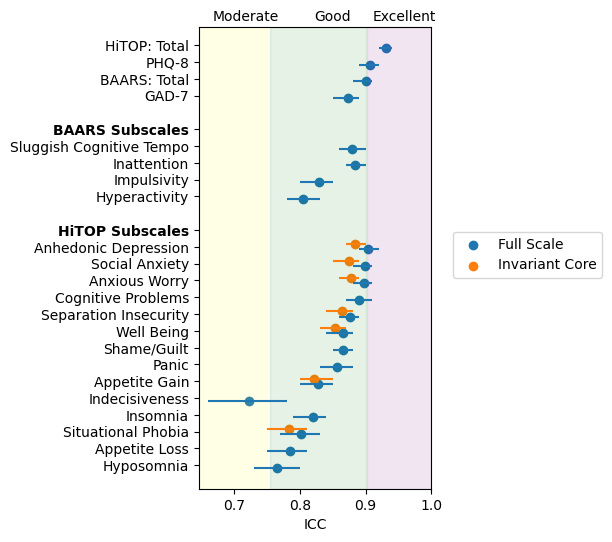

In [30]:
offset = 0.15
fig, ax = plt.subplots(1,figsize=(3,6))
ax.scatter(iccs.ICC_fs, iccs.plotting_order-offset, label='Full Scale')
ax.set_yticks(iccs.plotting_order.values.astype(int))
ax.set_yticklabels(iccs.measure_toplot)
ax.hlines(iccs.plotting_order-offset, iccs.lci_fs, iccs.uci_fs)

ax.scatter(iccs.ICC_ic, iccs.plotting_order+offset, color=sns.color_palette()[1], label='Invariant Core')
ax.hlines(iccs.plotting_order+offset, iccs.lci_ic, iccs.uci_ic, color=sns.color_palette()[1])

ax.get_ymajorticklabels()[4].set_weight('bold')
ax.get_ymajorticklabels()[9].set_weight('bold')

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.fill_betweenx(ylim,[0.5, 0.5] ,[0.75, 0.75], color='yellow', alpha=0.1)
ax.fill_betweenx(ylim,[0.755, 0.755] ,[0.9, 0.9], color='green', alpha=0.1)
ax.fill_betweenx(ylim,[0.902, 0.902] ,[1, 1], color='purple', alpha=0.1)


ax.set_ylim(ylim)
ax.set_xlim((xlim[0], 1))

fig.legend(loc='center left', bbox_to_anchor=(0.95, 0.5))
fig.text(0.28, 0.89, 'Moderate', ha='center')
fig.text(0.57, 0.89, 'Good', ha='center')
fig.text(0.81, 0.89, 'Excellent', ha='center')
ax.set_xlabel('ICC')

# alternative - indecisiveness on combined data

Text(0.5, 0, 'ICC')

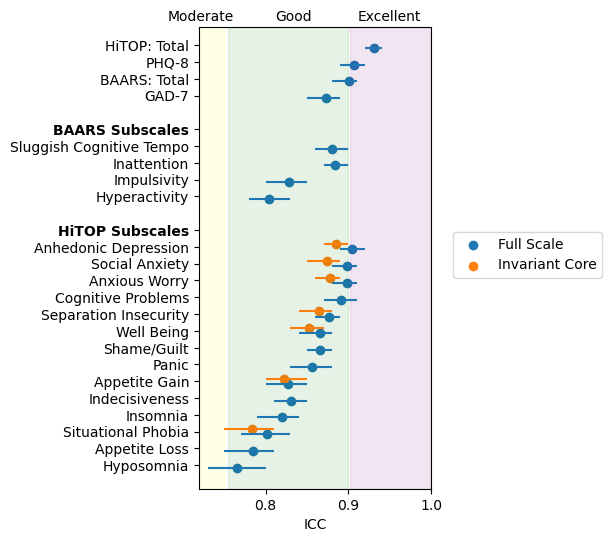

In [39]:
full_scales = pd.read_csv(data_dir / 'result_ICC_origscales_combined.csv')

iccs = full_scales.merge(cores.loc[:, ['Measure', 'ICC', 'uci', 'lci']], how='outer', on='Measure', suffixes=['_fs', '_ic'])
iccs = iccs.sort_values('ICC_fs').reset_index(drop=True)
iccs['full_scale_invariant'] = iccs.ICC_ic.isnull()

iccs['measure_toplot'] = iccs.Measure.replace(measure_dict)
iccs['plotting_order'] = iccs.Measure.replace(order_dict)

labels_df = pd.DataFrame(
    [{'measure_toplot': 'HiTOP Subscales', 'plotting_order':16},
     {'measure_toplot': 'BAARS Subscales', 'plotting_order':22},
    ]
)
iccs = pd.concat([iccs, labels_df])
iccs = iccs.sort_values('plotting_order', ascending=False).reset_index(drop=True)

offset = 0.15
fig, ax = plt.subplots(1,figsize=(3,6))
ax.scatter(iccs.ICC_fs, iccs.plotting_order-offset, label='Full Scale')
ax.set_yticks(iccs.plotting_order.values.astype(int))
ax.set_yticklabels(iccs.measure_toplot)
ax.hlines(iccs.plotting_order-offset, iccs.lci_fs, iccs.uci_fs)

ax.scatter(iccs.ICC_ic, iccs.plotting_order+offset, color=sns.color_palette()[1], label='Invariant Core')
ax.hlines(iccs.plotting_order+offset, iccs.lci_ic, iccs.uci_ic, color=sns.color_palette()[1])

ax.get_ymajorticklabels()[4].set_weight('bold')
ax.get_ymajorticklabels()[9].set_weight('bold')

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.fill_betweenx(ylim,[0.5, 0.5] ,[0.75, 0.75], color='yellow', alpha=0.1)
ax.fill_betweenx(ylim,[0.755, 0.755] ,[0.9, 0.9], color='green', alpha=0.1)
ax.fill_betweenx(ylim,[0.902, 0.902] ,[1, 1], color='purple', alpha=0.1)


ax.set_ylim(ylim)
ax.set_xlim((xlim[0], 1))

fig.legend(loc='center left', bbox_to_anchor=(0.95, 0.5))
fig.text(0.13, 0.89, 'Moderate', ha='center')
fig.text(0.44, 0.89, 'Good', ha='center')
fig.text(0.76, 0.89, 'Excellent', ha='center')
ax.set_xlabel('ICC')
